In [1]:
# --- parameters (patch_notebook_params.py) ---
MAX_EPOCHS = 2000
N_SAMPLES = 10           # run_metrics.py forces 50 for generative methods
RESET_TRAINING = False
CUDA_VISIBLE_DEVICES = "0"
METRICS_CSV = "results/metrics.csv"
SKIP_TRAINING = False    # run_metrics.py sets this True: load weights from
                         # the checkpoint directly instead of calling
                         # trainer.fit(), which can silently retrain for the
                         # full schedule if the checkpoint does not cleanly
                         # resume to exactly MAX_EPOCHS.


In [2]:
# Parameters
MAX_EPOCHS = 2000
N_SAMPLES = 20
RESET_TRAINING = False
CUDA_VISIBLE_DEVICES = "0"
METRICS_CSV = "/Odyssey/private/m19beauc/4dvarnet-starter-devs/consistency/sbatch_submission/results/GP/VarCM_metrics.csv"
SKIP_TRAINING = True
COND_MODE = "grad"


In [3]:
# --- epoch heartbeat (patch_notebook_params.py) ---
import pytorch_lightning as _pl

class EpochHeartbeat(_pl.Callback):
    """Prints one clear progress line every `every_n_epochs` epochs, so
    sbatch logs show training progress without the noise of a per-batch
    tqdm progress bar (which doesn't render well once redirected to a
    plain log file).    """

    def __init__(self, every_n_epochs: int = 1):
        self.every_n_epochs = every_n_epochs

    def on_train_epoch_end(self, trainer, pl_module):
        epoch = trainer.current_epoch + 1
        if epoch % self.every_n_epochs != 0 and epoch != trainer.max_epochs:
            return
        parts = []
        for k, v in sorted(trainer.callback_metrics.items()):
            try:
                parts.append(f'{k}={float(v):.4f}')
            except (TypeError, ValueError):
                pass
        print(f'[progress] epoch {epoch}/{trainer.max_epochs} | ' + ' | '.join(parts), flush=True)


# Pairwise Consistency Models & Variational Dynamics (VarCM)

---

## 1. Pairwise Consistency Model (PCM)

### 1.1 Motivation

Les modèles de consistance classiques (Song et al., 2023) apprennent à mapper tout échantillon bruité $\mathbf{x}_\sigma$ directement vers $\mathbf{x}_0$. Nous proposons une généralisation : la **consistance pairwise** entre deux niveaux de diffusion arbitraires $\sigma > \sigma'$, permettant d'apprendre les **sauts** entre niveaux.

> **Ce n'est pas du consistency model classique — c'est une nouvelle approche.**

### 1.2 Opérateur de transport pairwise

$$
g_\phi(\mathbf{x}_\sigma,\sigma,\sigma') =
\alpha(\sigma,\sigma')\,\mathbf{x}_\sigma +
\beta(\sigma,\sigma')\,G_\phi(\mathbf{x}_\sigma,\sigma,\sigma')
$$

$G_\phi$ est un UNet estimant le drift de transport $\sigma \to \sigma'$.

Le cas classique $f_\theta(\mathbf{x}_\sigma,\sigma) \approx \mathbf{x}_0$ est récupéré à $\sigma'=\sigma_{\min}$.

### 1.3 Loss pairwise

$$
\mathcal{L}_{\text{PCM}} =
\mathbb{E}\!\left[\left\| g_\phi(\mathbf{x}_\sigma,\sigma,\sigma'') - \mathrm{sg}\!\left[g_\phi(\mathbf{x}_{\sigma'},\sigma',\sigma'')\right] \right\|^2\right]
$$

Le teacher/student trick (EMA) stabilise la cible stop-gradient.

---

## 2. Pairwise Consistency en Dynamique Variationnelle (VarCM)

En CM classique, les paires $(\mathbf{x}_\sigma, \mathbf{x}_{\sigma'})$ sont disponibles analytiquement. En assimilation variationnelle, **pas de SDE forward explicite** : la dynamique est définie par le flot gradient d'un coût variationnel :

$$
J(\mathbf{x}) = \underbrace{\|\mathcal{H}\mathbf{x} - \mathbf{y}\|^2}_{\text{observation}} + \underbrace{\|\mathbf{x} - \Phi(\mathbf{x})\|^2}_{\text{prior (appris)}},
\qquad
\frac{d\mathbf{x}_t}{dt} = -\nabla_\mathbf{x} J(\mathbf{x}_t)
$$

On utilise une formulation **EMA teacher-free** pour entraîner sans processus forward connu.

### 2.1 Préconditionnement réseau & modes de conditionnement

Préconditionnement EDM avec interpolant linéaire $\alpha(t)=t$, $\beta(t)=1-t$ :

$$
c_\text{in}(t) = \frac{1}{\sqrt{\sigma_\text{data}^2(1-t)^2 + \sigma_\text{noise}^2\,t^2}}, \quad
c_\text{skip}(t,t') = \frac{\alpha(t')}{\alpha(t)}, \quad
c_\text{out}(t,t') = \beta(t') - c_\text{skip}\,\beta(t)
$$

L'opérateur de transport :
$$
g_\phi(\mathbf{x}_t,\, \mathbf{c},\, t, t') =
c_\text{skip}(t,t')\,\mathbf{x}_t + c_\text{out}(t,t')\,F_\theta\!\left(c_\text{in}(t)\,\mathbf{x}_t,\;\mathbf{c},\;t,\;t'\right)
$$

**Trois modes de conditionnement** (détecté automatiquement via `cond.shape[1]`) :

| Mode | Entrée $\mathbf{c}$ | Shape | Description |
|------|---------------------|-------|-------------|
| `"obs"` | $[\mathbf{y}_\text{filled},\, \mathbf{m}]$ | $(B, 2C, H, W)$ | Observations remplies + masque binaire |
| `"grad"` | $\nabla J(\mathbf{x}) / \|\nabla J\|$ | $(B, C, H, W)$ | Gradient variationnel normalisé |
| `"obs+grad"` | $[\mathbf{y}_\text{filled},\, \mathbf{m},\, \nabla J / \|\nabla J\|]$ | $(B, 3C, H, W)$ | Les deux combinés |

En mode `"obs+grad"`, le UNet somme `obs_projection(obs_part) + grad_j_projection(grad_part)` — **aucun paramètre supplémentaire**.

Conditions limites : $g_\phi(\mathbf{x}_t, \cdot, t, t) = \mathbf{x}_t$ (identité), $g_\phi(\mathbf{x}_t, \cdot, t, 0) = F_\theta(\cdot)$ (prédiction pure à l'échelle $\mathbf{x}_0$).

### 2.2 Loss déterministe : L_pair + L_anc + L_ae

**Philosophie clé :** $L_\text{pair}$ apprend toujours les **sauts pairwise** ; $L_\text{anc}$ ancre la solution.

**Choix design : toutes les prédictions à $t''=0$.**

À $t'=0$ : $c_\text{skip}=0$, $c_\text{out}=1$, donc $g_\phi(\cdot, t, 0) = F_\theta(\cdot)$ vit à l'échelle $\mathbf{x}_0$. Fixer $t''=0$ évite la *contradiction d'échelle*.

$$
\boxed{
\mathcal{L}_{\text{det}} =
\lambda_\text{pair}\underbrace{\left\|g_s(h_t, t, 0)
- \mathrm{sg}\!\left[g_t(h_{t'}, t', 0)\right]\right\|^2}_{L_\text{pair}}
+\,\lambda_\text{anc}\underbrace{\Bigl(
  \underbrace{\left\|g_s(h_t, t, 0) - \mathbf{x}_0\right\|^2}_{L_\text{long}}
  +\,\underbrace{\left\|g_s\!\bigl(\mathrm{sg}[g_s(h_t,t,t')],\,t',\,0\bigr) - \mathrm{sg}[g_t(h_{t'},t',0)]\right\|^2}_{L_\text{short}}
\Bigr)}_{L_\text{anc}}
+\,\lambda_\text{ae}\underbrace{\left\|\Phi(\mathbf{x}_0) - \mathbf{x}_0\right\|^2}_{L_\text{ae}}
}
$$

avec $h_t = \mathrm{sg}[g_t(\mathbf{x}_T, T, t)]$, $h_{t'} = \mathrm{sg}[g_t(\mathbf{x}_T, T, t')]$.

| Terme | Forward student | Cible | Rôle |
|-------|----------------|-------|------|
| $L_\text{pair}$ | $g_s(h_t, t, 0)$ | $\mathrm{sg}[g_t(h_{t'}, t', 0)]$ | **Sauts pairwise** : saut $t\!\to\!0$ ≈ saut $t'\!\to\!0$ |
| $L_\text{long}$ | $g_s(h_t, t, 0)$ *(partagé)* | $\mathbf{x}_0$ | Ancrage long : $\mathbf{x}_T\!\to\!t\!\to\!0 \approx \mathbf{x}_0$ |
| $L_\text{short}$ | $g_s(\mathrm{sg}[g_s(h_t,t,t')], t', 0)$ | $\mathrm{sg}[g_t(h_{t'},t',0)]$ | Ancrage court : deux sauts = un saut direct |
| $L_\text{ae}$ | $\Phi(\mathbf{x}_0)$ | $\mathbf{x}_0$ | Entraîne le prior $J_b$ |

$L_\text{pair}$ et $L_\text{long}$ partagent **le même forward student** : un appel UNet pour deux termes.

### 2.3 Loss stochastique : extension NLL (même structure)

Le réseau prédit $(\boldsymbol{\mu}_\phi, \sigma_\phi)$ et la NLL remplace le MSE pour les termes de consistance :

$$
\mathcal{L}_\text{stoch} = \lambda_\text{pair}\,L_\text{pair}^\text{NLL}
                         + \lambda_\text{anc}\,(L_\text{long}^\text{NLL} + L_\text{short}^\text{NLL})
                         + \lambda_\text{ae}\,L_\text{ae}
$$

où $\mathcal{L}_\text{NLL}(\mathbf{x}_\star, \boldsymbol{\mu}, \sigma) = \mathbb{E}\!\left[\dfrac{\|\mathbf{x}_\star - \boldsymbol{\mu}\|^2}{2\sigma^2} + \dfrac{d}{2}\log\sigma^2\right]$

| Terme det | Terme stoch | Forward partagé ? | Cible | σ apprend |
|-----------|-------------|-------------------|-------|-----------|
| $L_\text{pair}$ (MSE) | $L_\text{pair}^\text{NLL}$ | ✓ avec $L_\text{long}$ | cible teacher | calibrer σ vs erreur de saut |
| $L_\text{long}$ (MSE) | $L_\text{long}^\text{NLL}$ | ✓ avec $L_\text{pair}$ | $\mathbf{x}_0$ | calibrer σ vs erreur longue chaîne |
| $L_\text{short}$ (MSE) | $L_\text{short}^\text{NLL}$ | séparé | cible teacher | calibrer σ vs erreur courte chaîne |
| $L_\text{ae}$ (MSE) | $L_\text{ae}$ (MSE) | — | $\mathbf{x}_0$ | entraîne $\Phi$ |

### 2.4 Sampling déterministe vs stochastique

| Mode | Étapes intermédiaires | Étape finale ($t'\!\approx\!0$) |
|------|-----------------------|--------------------------------|
| ODE det | $\mathbf{x}_{t'} = c_\text{skip}\mathbf{x}_t + c_\text{out}\boldsymbol{\mu}_\phi$ | idem |
| ODE stoch | idem | idem |
| **SDE stoch** | idem ODE | $\mathbf{x}_0 = \boldsymbol{\mu}_\phi + \sigma_\phi\,\boldsymbol{\varepsilon},\;\boldsymbol{\varepsilon}\sim\mathcal{N}(0,\mathbf{I})$ |

σ injecté **uniquement à l'étape finale** : $L_\text{pair}^\text{NLL}+L_\text{long}^\text{NLL}+L_\text{short}^\text{NLL}$ supervisent $\sigma_\phi(\mathbf{x},t,0)$ mais pas $\sigma_\phi(\mathbf{x},t,t')$ pour $t'\!\neq\!0$.

### 2.5 Paramétrisations de covariance

| Type | Forme | Loss |
|------|-------|------|
| **Isotrope** *(implémenté)* | $\boldsymbol{\Sigma} = \sigma^2\,\mathbf{I}$ | $\|\mathbf{x}-\boldsymbol{\mu}\|^2/(2\sigma^2) + (d/2)\log\sigma^2$ |
| **Diagonale** | $\boldsymbol{\Sigma} = \mathrm{diag}(\sigma_i^2)$ | MSE pondéré + $\sum_i\log\sigma_i^2$ |
| **Structurée (SPDE)** | $\boldsymbol{\Sigma}^{-1} = \alpha_\phi\,\mathcal{L}_\phi$ | NLL pondérée par précision |

---


In [4]:
!nvidia-smi

Fri Aug 21 15:51:32 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.158.01             Driver Version: 570.158.01     CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:C8:00.0 Off |                    0 |
| N/A   42C    P0             70W /  400W |       0MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [5]:
import os; os.environ["CUDA_VISIBLE_DEVICES"] = CUDA_VISIBLE_DEVICES

In [6]:
import json
import math
import os
import zipfile
import glob
import importlib
from dataclasses import asdict, dataclass
from typing import Any, Callable, List, Optional, Tuple, Union

import numpy as np
import xarray as xr
import pandas as pd
import torch
from einops import rearrange
from einops.layers.torch import Rearrange
import pytorch_lightning as pl
from pytorch_lightning import LightningModule, Trainer, seed_everything
from pytorch_lightning.callbacks import LearningRateMonitor, ModelCheckpoint
from pytorch_lightning.loggers import TensorBoardLogger
from matplotlib import pyplot as plt
from torch import Tensor, nn
from torch.nn import functional as F
from torchinfo import summary

import sys
sys.path.append('../..')    # -> consistency/
sys.path.append('../../..')  # -> 4dvarnet-starter-devs/

import consistency_models.consistency_models_VarCM as _cm_var
importlib.reload(_cm_var)

from consistency_models.consistency_models_VarCM import (
    VariationalConsistencySampling,
    model_variational_forward_wrapper,
)
from consistency_models.utils import update_ema_model_

try:
    from properscoring import crps_ensemble
    HAS_PROPERSCORING = True
except ImportError:
    HAS_PROPERSCORING = False
    print("[WARNING] properscoring not installed -- CRPS disabled. Install with: pip install properscoring")


## Implementation

### DataModule -- SPDE Diffusion Dataset

In [7]:
from src.data_notebook_spde import SPDEDataModule

SPDE_PATH = "../../../data/SPDE_diffusion_dataset_1.nc"

ds_inspect = xr.open_dataset(SPDE_PATH)
print(ds_inspect)
print("\nVariables:")
for v in ds_inspect.data_vars:
    print(f"  {v}: {ds_inspect[v].dims}  shape={ds_inspect[v].shape}  dtype={ds_inspect[v].dtype}")
ds_inspect.close()

<xarray.Dataset>
Dimensions:    (time: 300, lat: 128, lon: 128)
Coordinates:
  * lon        (lon) int64 0 1 2 3 4 5 6 7 8 ... 120 121 122 123 124 125 126 127
  * lat        (lat) int64 0 1 2 3 4 5 6 7 8 ... 120 121 122 123 124 125 126 127
  * time       (time) int64 0 1 2 3 4 5 6 7 ... 292 293 294 295 296 297 298 299
Data variables:
    x          (time, lat, lon) float32 ...
    y          (time, lat, lon) float32 ...
    OI         (time, lat, lon) float64 ...
    H11        (lat, lon) float32 ...
    H22        (lat, lon) float32 ...
    H12        (lat, lon) float32 ...
    Time       (time) int64 ...
    longitude  (lon) int64 ...
    latitude   (lat) int64 ...
Attributes:
    description:  SPDE-based diffusion GP

Variables:
  x: ('time', 'lat', 'lon')  shape=(300, 128, 128)  dtype=float32
  y: ('time', 'lat', 'lon')  shape=(300, 128, 128)  dtype=float32
  OI: ('time', 'lat', 'lon')  shape=(300, 128, 128)  dtype=float64
  H11: ('lat', 'lon')  shape=(128, 128)  dtype=float32
  H22

[SPDEDataModule] T=300, window=5, stride=1 → 296 windows: train=207, val=44, test=45
[SPDEDataModule] Norm stats (mean, std): (-0.00018237734911963344, 0.249156191945076)


window_size (C) = 5
TrainingItem shapes -- input (y): (5, 128, 128), tgt (x): (5, 128, 128)


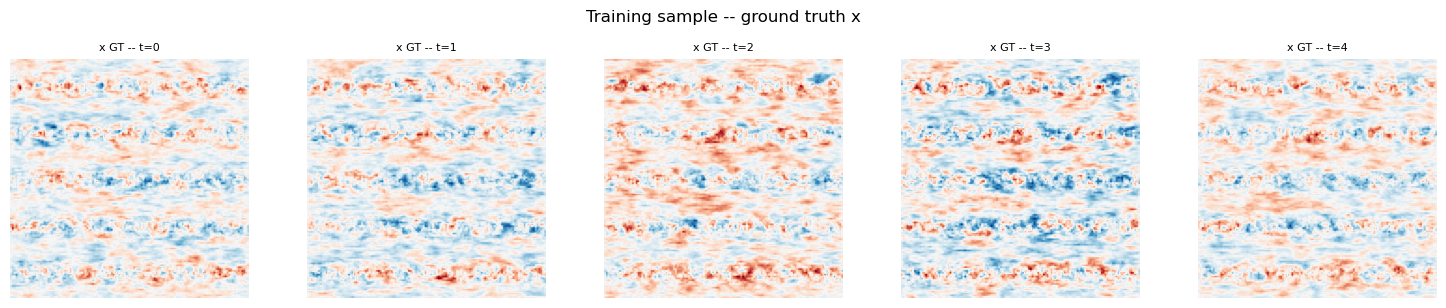

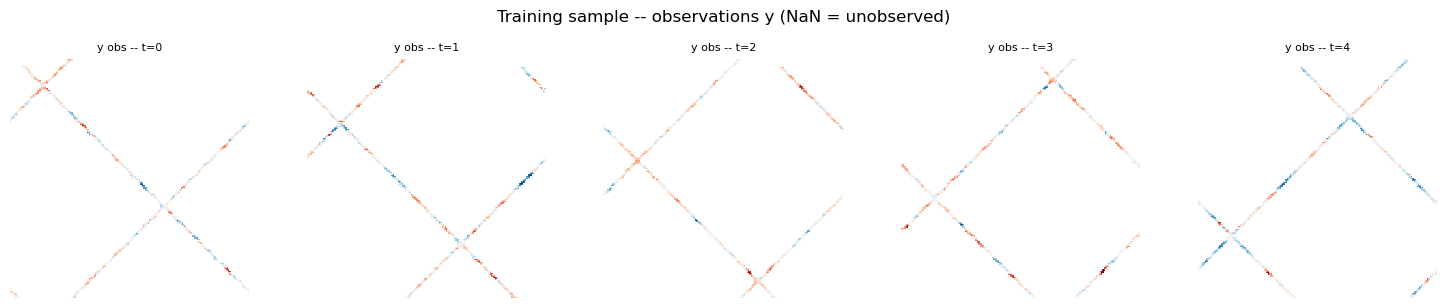

In [8]:
datamodule = SPDEDataModule(
    path=SPDE_PATH,
    window_size=5,
    stride=1,
    train_ratio=0.7,
    val_ratio=0.15,
    dl_kw={"batch_size": 1, "num_workers": 1},
)
datamodule.setup()

sample = datamodule.train_ds[0]
C = datamodule.window_size
print(f"window_size (C) = {C}")
print(f"TrainingItem shapes -- input (y): {sample.input.shape}, tgt (x): {sample.tgt.shape}")

fig, axes = plt.subplots(1, C, figsize=(3 * C, 3))
for t_idx, ax in enumerate(axes):
    ax.imshow(sample.tgt[t_idx], origin="lower", cmap="RdBu_r")
    ax.set_title(f"x GT -- t={t_idx}", fontsize=8)
    ax.axis("off")
plt.suptitle("Training sample -- ground truth x", y=1.01)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, C, figsize=(3 * C, 3))
for t_idx, ax in enumerate(axes):
    ax.imshow(sample.input[t_idx], origin="lower", cmap="RdBu_r")
    ax.set_title(f"y obs -- t={t_idx}", fontsize=8)
    ax.axis("off")
plt.suptitle("Training sample -- observations y (NaN = unobserved)", y=1.01)
plt.tight_layout()
plt.show()

### UNet Building Blocks

GroupNorm, SelfAttention, UNetBlock, Downsample, Upsample, `TimeEmbedding` (for **t** and **t'** separately), `_pad_to_multiple`, `_unpad`.

In [9]:
def GroupNorm(channels: int) -> nn.GroupNorm:
    return nn.GroupNorm(num_groups=min(32, channels // 4), num_channels=channels)


class SelfAttention(nn.Module):
    def __init__(self, in_channels: int, out_channels: int,
                 n_heads: int = 8, dropout: float = 0.3) -> None:
        super().__init__()
        self.dropout = dropout
        self.qkv_projection = nn.Sequential(
            GroupNorm(in_channels),
            nn.Conv2d(in_channels, 3 * in_channels, kernel_size=1, bias=False),
            Rearrange("b (i h d) x y -> i b h (x y) d", i=3, h=n_heads),
        )
        self.output_projection = nn.Sequential(
            Rearrange("b h l d -> b l (h d)"),
            nn.Linear(in_channels, out_channels, bias=False),
            Rearrange("b l d -> b d l"),
            GroupNorm(out_channels),
            nn.Dropout1d(dropout),
        )
        self.residual_projection = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x: Tensor) -> Tensor:
        q, k, v = self.qkv_projection(x).unbind(dim=0)
        output = F.scaled_dot_product_attention(
            q, k, v, dropout_p=self.dropout if self.training else 0.0, is_causal=False
        )
        output = self.output_projection(output)
        output = rearrange(output, "b c (x y) -> b c x y", x=x.shape[-2], y=x.shape[-1])
        return output + self.residual_projection(x)


class UNetBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int,
                 time_level_channels: int, dropout: float = 0.3) -> None:
        super().__init__()
        self.input_projection = nn.Sequential(
            GroupNorm(in_channels), nn.SiLU(),
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding="same"),
            nn.Dropout2d(dropout),
        )
        self.time_level_projection = nn.Sequential(
            nn.SiLU(),
            nn.Conv2d(time_level_channels, out_channels, kernel_size=1),
        )
        self.output_projection = nn.Sequential(
            GroupNorm(out_channels), nn.SiLU(),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding="same"),
            nn.Dropout2d(dropout),
        )
        self.residual_projection = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x: Tensor, time_level: Tensor) -> Tensor:
        h = self.input_projection(x)
        h = h + self.time_level_projection(time_level)
        return self.output_projection(h) + self.residual_projection(x)


class UNetBlockWithSelfAttention(nn.Module):
    def __init__(self, in_channels: int, out_channels: int,
                 time_level_channels: int, n_heads: int = 8, dropout: float = 0.3) -> None:
        super().__init__()
        self.unet_block = UNetBlock(in_channels, out_channels, time_level_channels, dropout)
        self.self_attention = SelfAttention(out_channels, out_channels, n_heads, dropout)

    def forward(self, x: Tensor, time_level: Tensor) -> Tensor:
        return self.self_attention(self.unet_block(x, time_level))


class Downsample(nn.Module):
    def __init__(self, channels: int) -> None:
        super().__init__()
        self.projection = nn.Sequential(
            Rearrange("b c (h ph) (w pw) -> b (c ph pw) h w", ph=2, pw=2),
            nn.Conv2d(4 * channels, channels, kernel_size=1),
        )

    def forward(self, x: Tensor) -> Tensor:
        return self.projection(x)


class Upsample(nn.Module):
    def __init__(self, channels: int) -> None:
        super().__init__()
        self.projection = nn.Sequential(
            nn.Upsample(scale_factor=2.0, mode="nearest"),
            nn.Conv2d(channels, channels, kernel_size=3, padding="same"),
        )

    def forward(self, x: Tensor) -> Tensor:
        return self.projection(x)


class TimeEmbedding(nn.Module):
    """Fourier time embedding for a scalar t in [0, 1]."""
    def __init__(self, channels: int, scale: float = 16.0) -> None:
        super().__init__()
        self.W = nn.Parameter(torch.randn(channels // 2) * scale, requires_grad=False)
        self.projection = nn.Sequential(
            nn.Linear(channels, 4 * channels),
            nn.SiLU(),
            nn.Linear(4 * channels, channels),
            Rearrange("b c -> b c () ()"),
        )

    def forward(self, x: Tensor) -> Tensor:
        h = x[:, None] * self.W[None, :] * 2 * torch.pi
        h = torch.cat([torch.sin(h), torch.cos(h)], dim=-1)
        return self.projection(h)


# ---- Padding utilities (100x100 -> 104x104, multiple of 8) ----
def _pad_to_multiple(x: Tensor, multiple: int = 8) -> Tuple[Tensor, Tuple[int, int, int, int]]:
    _, _, H, W = x.shape
    pad_h = (multiple - H % multiple) % multiple
    pad_w = (multiple - W % multiple) % multiple
    padding = (0, pad_w, 0, pad_h)
    return F.pad(x, padding, mode="reflect"), padding


def _unpad(x: Tensor, padding: Tuple[int, int, int, int]) -> Tensor:
    _, pad_w, _, pad_h = padding
    H, W = x.shape[-2], x.shape[-1]
    return x[..., :H - pad_h if pad_h else H, :W - pad_w if pad_w else W]

### Variational UNet

Differences vs the classic PWCM UNet:
- **`input_projection`**: takes `c_in(t) * x` -- **C** channels (not 3C)
- **`grad_j_projection`**: takes `grad_J` -- **C** channels, added to the output of `input_projection`
- **Two `TimeEmbedding`**: one for `t`, one for `t'`, concatenated -> `2 x time_level_channels`
- No observations y in the forward pass (handled upstream via `model_variational_forward_wrapper`)

In [10]:
@dataclass
class UNetConfig:
    channels: int = 5                                        # = window_size
    time_level_channels: int = 128
    time_level_scale: float = 16.0
    n_heads: int = 8
    top_blocks_channels: Tuple[int, ...] = (64, 64)
    top_blocks_n_blocks_per_resolution: Tuple[int, ...] = (2, 2)
    top_blocks_has_resampling: Tuple[bool, ...] = (True, True)
    top_blocks_dropout: Tuple[float, ...] = (0.0, 0.0)
    mid_blocks_channels: Tuple[int, ...] = (128, 256)
    mid_blocks_n_blocks_per_resolution: Tuple[int, ...] = (4, 4)
    mid_blocks_has_resampling: Tuple[bool, ...] = (True, False)
    mid_blocks_dropout: Tuple[float, ...] = (0.0, 0.0)
    stoch: bool = False   # If True: outputs (mu, log_sigma) for stochastic VarCM


class UNet(nn.Module):
    """
    Variational UNet: takes (c_in*x, cond, t, t') as input.

    Two conditioning modes (selected automatically from cond.shape[1]):
      - grad mode : cond = grad_J  (C channels)  -> grad_j_projection (C -> top)
      - obs  mode : cond = cat([y_filled, mask])  (2C channels) -> obs_projection (2C -> top)

    - input_projection  : C  -> top_ch[0]  (for c_in*x)
    - Two TimeEmbedding concatenated -> conditioning 2xTLC

    Stochastic mode (config.stoch=True):
      An additional scalar head (global-avg-pool + MLP) predicts log σ per sample.
      forward() returns (mu: (B,C,H,W), log_sigma: (B,1)) instead of a single Tensor.
    """
    def __init__(self, config: UNetConfig) -> None:
        super().__init__()
        self.config = config
        C   = config.channels
        top = config.top_blocks_channels[0]

        # x projection (always C channels)
        self.input_projection  = nn.Conv2d(C,     top, kernel_size=3, padding="same")
        # grad mode: C channels  (grad_J, normalised to unit std)
        self.grad_j_projection = nn.Conv2d(C,     top, kernel_size=3, padding="same")
        # obs  mode: 2C channels (y_filled + mask)
        self.obs_projection    = nn.Conv2d(2 * C, top, kernel_size=3, padding="same")

        # One embedding per solver time (t and t')
        self.time_embedding_t  = TimeEmbedding(config.time_level_channels, config.time_level_scale)
        self.time_embedding_tp = TimeEmbedding(config.time_level_channels, config.time_level_scale)

        self.top_encoder_blocks = self._make_encoder_blocks(
            config.top_blocks_channels + config.mid_blocks_channels[:1],
            config.top_blocks_n_blocks_per_resolution,
            config.top_blocks_has_resampling,
            config.top_blocks_dropout, self._make_top_block,
        )
        self.mid_encoder_blocks = self._make_encoder_blocks(
            config.mid_blocks_channels + config.mid_blocks_channels[-1:],
            config.mid_blocks_n_blocks_per_resolution,
            config.mid_blocks_has_resampling,
            config.mid_blocks_dropout, self._make_mid_block,
        )
        self.mid_decoder_blocks = self._make_decoder_blocks(
            config.mid_blocks_channels + config.mid_blocks_channels[-1:],
            config.mid_blocks_n_blocks_per_resolution,
            config.mid_blocks_has_resampling,
            config.mid_blocks_dropout, self._make_mid_block,
        )
        self.top_decoder_blocks = self._make_decoder_blocks(
            config.top_blocks_channels + config.mid_blocks_channels[:1],
            config.top_blocks_n_blocks_per_resolution,
            config.top_blocks_has_resampling,
            config.top_blocks_dropout, self._make_top_block,
        )
        self.output_projection = nn.Conv2d(top, C, kernel_size=3, padding="same")

        # Stochastic head: predict scalar log σ from pooled decoder features
        if config.stoch:
            self.log_sigma_head = nn.Sequential(
                nn.AdaptiveAvgPool2d(1),   # (B, top, H, W) -> (B, top, 1, 1)
                nn.Flatten(),              # -> (B, top)
                nn.Linear(top, top // 4),
                nn.SiLU(),
                nn.Linear(top // 4, 1),   # -> (B, 1)  scalar log σ
            )

    def forward(self, x: Tensor, cond: Tensor, t: Tensor, t_prime: Tensor
                ) -> Union[Tensor, Tuple[Tensor, Tensor]]:
        """
        x    : (B, C,   H, W)  -- c_in(t) * current state
        cond : (B, C,   H, W)  -- grad_J  (grad mode, C channels)
             | (B, 2C,  H, W)  -- cat([y_filled, mask])  (obs mode, 2C channels)
        t, t_prime : (B,)

        Returns:
          stoch=False : out          (B, C, H, W)
          stoch=True  : (mu, log_σ)  (B,C,H,W),  (B,1)
        """
        x,    px = _pad_to_multiple(x,    multiple=8)
        cond, _  = _pad_to_multiple(cond, multiple=8)

        # Route conditioning to the appropriate projection
        if cond.shape[1] == self.config.channels:
            cond_proj = self.grad_j_projection(cond)
        else:
            cond_proj = self.obs_projection(cond)

        h = self.input_projection(x) + cond_proj

        # Conditioning: t and t' -> concat on channel dim
        emb_t  = self.time_embedding_t(t)
        emb_tp = self.time_embedding_tp(t_prime)
        time_level = torch.cat([emb_t, emb_tp], dim=1)   # (B, 2*TLC, 1, 1)

        top_encoder_embeddings = []
        for block in self.top_encoder_blocks:
            if isinstance(block, UNetBlock):
                h = block(h, time_level)
                top_encoder_embeddings.append(h)
            else:
                h = block(h)

        mid_encoder_embeddings = []
        for block in self.mid_encoder_blocks:
            if isinstance(block, UNetBlockWithSelfAttention):
                h = block(h, time_level)
                mid_encoder_embeddings.append(h)
            else:
                h = block(h)

        for block in self.mid_decoder_blocks:
            if isinstance(block, UNetBlockWithSelfAttention):
                h = torch.cat((h, mid_encoder_embeddings.pop()), dim=1)
                h = block(h, time_level)
            else:
                h = block(h)

        for block in self.top_decoder_blocks:
            if isinstance(block, UNetBlock):
                h = torch.cat((h, top_encoder_embeddings.pop()), dim=1)
                h = block(h, time_level)
            else:
                h = block(h)

        out = self.output_projection(h)
        out = _unpad(out, px)

        if self.config.stoch:
            log_sigma = self.log_sigma_head(h)   # (B, 1)
            return out, log_sigma

        return out

    # ---- builder helpers ----
    def _make_encoder_blocks(self, channels, n_blocks, has_resampling, dropout, block_fn):
        blocks = nn.ModuleList()
        for idx, (ic, oc) in enumerate(zip(channels[:-1], channels[1:])):
            for _ in range(n_blocks[idx]):
                blocks.append(block_fn(ic, oc, dropout[idx]))
                ic = oc
            if has_resampling[idx]:
                blocks.append(Downsample(oc))
        return blocks

    def _make_decoder_blocks(self, channels, n_blocks, has_resampling, dropout, block_fn):
        blocks = nn.ModuleList()
        for idx, (oc, ic) in enumerate(list(zip(channels[:-1], channels[1:]))[::-1]):
            if has_resampling[::-1][idx]:
                blocks.append(Upsample(ic))
            inner = []
            for _ in range(n_blocks[::-1][idx]):
                inner.append(block_fn(ic * 2, oc, dropout[::-1][idx]))
                oc = ic
            blocks.extend(inner[::-1])
        return blocks

    def _make_top_block(self, ic, oc, dropout):
        return UNetBlock(ic, oc, 2 * self.config.time_level_channels, dropout)

    def _make_mid_block(self, ic, oc, dropout):
        return UNetBlockWithSelfAttention(
            ic, oc, 2 * self.config.time_level_channels, self.config.n_heads, dropout
        )

    def save_pretrained(self, pretrained_path: str) -> None:
        os.makedirs(pretrained_path, exist_ok=True)
        with open(os.path.join(pretrained_path, "config.json"), mode="w") as f:
            json.dump(asdict(self.config), f)
        torch.save(self.state_dict(), os.path.join(pretrained_path, "model.pt"))

    @classmethod
    def from_pretrained(cls, pretrained_path: str) -> "UNet":
        with open(os.path.join(pretrained_path, "config.json"), mode="r") as f:
            config_dict = json.load(f)
        model = cls(UNetConfig(**config_dict))
        model.load_state_dict(
            torch.load(os.path.join(pretrained_path, "model.pt"), map_location="cpu")
        )
        return model


# Sanity check -- test both conditioning modes (stoch=False, default)
C = datamodule.window_size
_unet = UNet(UNetConfig(channels=C))
summary(
    _unet,
    input_size=(
        (1, C, 100, 100),       # x (c_in * x)
        (1, C, 100, 100),       # cond: grad mode (C channels)
        (1,),                    # t
        (1,),                    # t'
    ),
    col_names=["input_size", "output_size", "num_params"],
    verbose=0,
)
_unet = _unet.cpu()

# Stochastic mode check
_unet_s = UNet(UNetConfig(channels=C, stoch=True))
_x_dummy  = torch.randn(1, C, 100, 100)
_cond_obs = torch.randn(1, 2 * C, 100, 100)
_t_dummy  = torch.rand(1)
with torch.no_grad():
    _mu, _log_sigma = _unet_s(_x_dummy, _cond_obs, _t_dummy, _t_dummy)
print(f"[OK] UNet stoch=True: mu {_mu.shape}  log_sigma {_log_sigma.shape}")
_unet_s = _unet_s.cpu()


[OK] UNet stoch=True: mu torch.Size([1, 5, 100, 100])  log_sigma torch.Size([1, 1])


### Variational Costs

- **`BaseObsCost`**: $J_o(x, y) = \|M(x - y)\|^2$ (NaN mask)
- **`BilinAEPriorCost`**: $J_b(x) = \|x - \Phi(x)\|^2$ with $\Phi$ = bilinear auto-encoder
- **`lambda_reg`**: `nn.Parameter` scalar $\geq 0$ weighting $J_b$ in $J = J_o + \lambda J_b$

In [11]:
class BaseObsCost(nn.Module):
    """
    Quadratic observation cost: J_o(x, y) = ||M*(x - y)||^2 / (2 * sigma_obs^2)
    M = binary mask (1 where y is observed, 0 where y is NaN).
    """
    def __init__(self, sigma_obs: float = 1.0) -> None:
        super().__init__()
        self.sigma_obs = sigma_obs

    def forward(self, x: Tensor, y: Tensor) -> Tensor:
        """Returns a scalar."""
        mask = (~torch.isnan(y)).to(dtype=x.dtype)
        y_c  = torch.nan_to_num(y, nan=0.0)
        diff = mask * (x - y_c)
        return (diff ** 2).sum() / (2.0 * self.sigma_obs ** 2)


class BilinAEPriorCost(nn.Module):
    """
    Prior cost based on a bilinear auto-encoder:
        J_b(x) = ||x - Phi(x)||^2

    Phi = standard BilinAE (Conv encoder -> Conv decoder with bilinear interaction).
    dim_in: number of input channels (= window_size)
    """
    def __init__(self, dim_in: int = 5, dim_ae: int = 32) -> None:
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(dim_in, dim_ae, 3, padding=1), nn.SiLU(),
            nn.Conv2d(dim_ae, dim_ae, 3, padding=1), nn.SiLU(),
        )
        self.decoder_lin = nn.Sequential(
            nn.Conv2d(dim_ae, dim_ae, 3, padding=1), nn.SiLU(),
            nn.Conv2d(dim_ae, dim_in, 3, padding=1),
        )
        self.decoder_quad = nn.Sequential(
            nn.Conv2d(dim_ae, dim_ae, 3, padding=1), nn.SiLU(),
            nn.Conv2d(dim_ae, dim_in, 3, padding=1),
        )

    def forward_ae(self, x: Tensor) -> Tensor:
        """Returns Phi(x)."""
        z = self.encoder(x)
        return self.decoder_lin(z) + self.decoder_quad(z) ** 2

    def forward(self, x: Tensor) -> Tensor:
        """Returns J_b(x) = ||x - Phi(x)||^2 (scalar)."""
        recon = self.forward_ae(x)
        return F.mse_loss(x, recon) * x.numel()


# Sanity check
C = datamodule.window_size
_x_test = torch.randn(2, C, 100, 100)
_y_test = torch.randn(2, C, 100, 100)
_y_test[0, :, :10, :10] = float('nan')   # simulate NaN observations
_obs  = BaseObsCost(sigma_obs=1.0)
_prior = BilinAEPriorCost(dim_in=C)
print("J_o =", _obs(_x_test, _y_test).item())
print("J_b =", _prior(_x_test).item())
print("Phi(x) shape =", _prior.forward_ae(_x_test).shape)

J_o = 99912.5625
J_b = 99974.9140625
Phi(x) shape = torch.Size([2, 5, 100, 100])


### Deterministic VarCM — Loss : L_pair + L_anc + L_ae

Nouvelle approche : **Pairwise Consistency** — on n'apprend pas un débruiteur classique, on apprend les **sauts pairwise** entre niveaux de bruit.

$$
\mathcal{L}_\text{det} = \lambda_\text{pair}\,L_\text{pair} + \lambda_\text{anc}\,L_\text{anc} + \lambda_\text{ae}\,L_\text{ae}
$$

| Terme | Appel student | Cible | Rôle |
|-------|--------------|-------|------|
| $L_\text{pair}$ | $g_s(h_t,\, t,\, 0)$ | $\mathrm{sg}[g_t(h_{t'},\, t',\, 0)]$ | **Apprend les sauts pairwise** : saut $t\!\to\!0$ ≈ saut $t'\!\to\!0$ |
| $L_\text{anc} = L_\text{long} + L_\text{short}$ | *long* : $g_s(h_t, t, 0)$ *(partagé)* ; *short* : $g_s(\mathrm{sg}[g_s(h_t,t,t')], t', 0)$ | $\mathbf{x}_0$ / $\mathrm{sg}[g_t(h_{t'},t',0)]$ | Ancrage : évite la dérive de l'EMA teacher |
| $L_\text{ae}$ | $\Phi(\mathbf{x}_0)$ | $\mathbf{x}_0$ | Entraîne le coût prior $J_b$ |

$L_\text{pair}$ et $L_\text{long}$ partagent **le même forward student** : un seul appel UNet pour deux termes.

**Conditionnement :** `conditioning_mode` ∈ `{"obs", "grad", "obs+grad"}` — voir Section 2.1.


In [12]:
import importlib
import consistency_models.consistency_models_VarCM as _vcm_mod
importlib.reload(_vcm_mod)

from consistency_models.consistency_models_VarCM import (
    DEFAULT_SCHEDULE,
    model_variational_forward_wrapper,
    _g_fwd as _g,
    VarCMOutput,
    VarCMTraining,
)
from consistency_models.utils import karras_schedule, timesteps_schedule
from consistency_models.consistency_models_CM import ema_decay_rate_schedule

# ── Sanity check ────────────────────────────────────────────────────────────
C = datamodule.window_size
_vct = VarCMTraining(initial_timesteps=3, final_timesteps=5,
                     sigma_noise=80.0, conditioning_mode="obs",
                     lambda_pair=1.0, lambda_anc=1.0, lambda_ae=0.5,
                     pure_short=True)
_unet_stu = UNet(UNetConfig(channels=C))
_unet_tch = UNet(UNetConfig(channels=C))
_unet_tch.load_state_dict(_unet_stu.state_dict())
_oc = BaseObsCost(); _pc = BilinAEPriorCost(dim_in=C)
_lr = nn.Parameter(torch.tensor(1.0))
_b  = next(iter(datamodule.train_dataloader()))
with torch.no_grad():
    _out = _vct(_unet_stu, _unet_tch, _oc, _pc, _lr,
                _b.tgt, _b.input, global_step=0, total_steps=5000)
print(f"[OK] VarCMTraining (L_pair + L_anc + L_ae):\n"
      f"  loss={_out.loss.item():.4f}  N={_out.num_timesteps}\n"
      f"  L_pair={_out.l_pair.item():.4f}  "
      f"L_anc={_out.l_anc.item():.4f}  "
      f"(L_long={_out.l_long.item():.4f}  L_short={_out.l_short.item():.4f})  "
      f"L_ae={_out.l_ae.item():.4f}")
del _vct, _unet_stu, _unet_tch, _oc, _pc, _lr, _b, _out


[OK] VarCMTraining (L_pair + L_anc + L_ae):
  loss=1.8471  N=3
  L_pair=0.5460  L_anc=0.7989  (L_long=0.6856  L_short=0.1133)  L_ae=1.0043


### LightningModule -- LitConsistencyModel (Variational)

In [13]:
from consistency_models.consistency_models_VarCM import LitVarCMConfig, LitVarCM


## Training

In [14]:
import importlib
import glob
import consistency_models.consistency_models_VarCM as _vcm_mod
importlib.reload(_vcm_mod)
from consistency_models.consistency_models_VarCM import VariationalConsistencySampling

# ── Helper: find best or last checkpoint ────────────────────────────────────
def _is_valid_ckpt(path: str) -> bool:
    """Return True if the checkpoint is a readable zip archive."""
    import zipfile
    try:
        with zipfile.ZipFile(path): pass
        return True
    except Exception:
        return False

def find_best_valid_checkpoint(ckpt_dir: str, use_last: bool = True):
    """Return the path of the last (or best) valid checkpoint, or None if not found."""
    if not os.path.isdir(ckpt_dir):
        print(f"[INFO] No checkpoint dir found at {ckpt_dir!r} — starting from scratch.")
        return None
    if use_last:
        last = os.path.join(ckpt_dir, "last.ckpt")
        if os.path.isfile(last):
            if _is_valid_ckpt(last):
                print(f"[RESUME] last checkpoint: {last}")
                return last
            print(f"[WARN] last.ckpt is corrupted — falling back to best checkpoint.")
    # Fall back to best by train_loss (lowest value in filename)
    ckpts = glob.glob(os.path.join(ckpt_dir, "*.ckpt"))
    ckpts = [c for c in ckpts if "last" not in os.path.basename(c) and _is_valid_ckpt(c)]
    if not ckpts:
        print(f"[INFO] No valid checkpoint found in {ckpt_dir!r} — starting from scratch.")
        return None
    best = min(ckpts, key=lambda p: float(p.split("train_loss=")[-1].replace(".ckpt", "")) if "train_loss=" in p else float("inf"))
    print(f"[RESUME] best checkpoint: {best}")
    return best

# RESET_TRAINING set by the parameters cell above
C = datamodule.window_size

COND_MODE   = "grad"  # "obs" | "grad" | "obs+grad"

# ── Noise scale ───────────────────────────────────────────────────────────────
# v3: sigma_noise 80→10.  With data normalised to std~1, sigma_noise=80 gives
# SNR(t=0.5)=0.06% — the model learns from essentially pure noise throughout.
# sigma_noise=10 gives SNR(t=0.5)=4% — 64x easier, still fully stochastic at T=1.
SIGMA_NOISE = 10.0

LOG_DIR     = f"logs_CT_VarCM_spde_{COND_MODE.replace('+', '_')}"
CKPT_DIR    = os.path.join(LOG_DIR, "checkpoints")
MODEL_PATH  = os.path.join(LOG_DIR, "best_model")

if RESET_TRAINING:
    import shutil
    for d in [CKPT_DIR, MODEL_PATH]:
        if os.path.exists(d):
            shutil.rmtree(d)
            print(f"[DELETE] Removed: {d}")
    resume_ckpt = None
    print("[RESET] Starting from scratch.")
else:
    resume_ckpt = find_best_valid_checkpoint(CKPT_DIR)

# ── Schedule ─────────────────────────────────────────────────────────────────
# schedule_power: 1.0 = uniform linear grid; 2.0 = finer steps near t=0
SCHEDULE_POWER = 1.0

# ── VarCMTraining ─────────────────────────────────────────────────────────────
# v5 changes vs v4:
#   - normalisation séparée de ∇Jo et ∇Jb : chacun normalisé à std=1
#     avant sommation → pondération équilibrée, évite que ∇Jb (prior SPDE appris)
#     domine sur ∇Jo (fit aux observations)
ct = VarCMTraining(
    initial_timesteps = 5,
    final_timesteps   = 50,
    sigma_noise       = SIGMA_NOISE,
    lambda_pair       = 1.0,    # Term 1: pairwise consistency
    lambda_anc        = 1.0,    # Term 2: long+short anchor
    lambda_ae         = 1.0,    # Term 3: AE reconstruction — trains prior_cost
    lambda_obs        = 1.0,    # Term 4: anchors x_0 to observations
    schedule_power    = SCHEDULE_POWER,
    conditioning_mode = COND_MODE,
)

# ── Models ────────────────────────────────────────────────────────────────────
student_model     = UNet(UNetConfig(channels=C))
teacher_model     = UNet(UNetConfig(channels=C))
ema_student_model = UNet(UNetConfig(channels=C))
teacher_model.load_state_dict(student_model.state_dict())
ema_student_model.load_state_dict(student_model.state_dict())

# ── Variational costs ─────────────────────────────────────────────────────────
obs_cost   = BaseObsCost(sigma_obs=1.0)
prior_cost = BilinAEPriorCost(dim_in=C)

# ── LightningModule ────────────────────────────────────────────────────────────
lit_cm = LitVarCM(
    ct,
    student_model,
    teacher_model,
    ema_student_model,
    obs_cost,
    prior_cost,
    LitVarCMConfig(lr_scheduler_iters=1000),
)

trainer = Trainer(enable_progress_bar=False, 
    accelerator             = "gpu",
    max_epochs=MAX_EPOCHS,
    accumulate_grad_batches = 4,
    precision               = "bf16-mixed",
    gradient_clip_val       = 0.5,    # was 1.0
    gradient_clip_algorithm = "norm",
    log_every_n_steps       = 1,
    logger   = TensorBoardLogger(".", name=LOG_DIR, version=""),
    callbacks = [
        LearningRateMonitor(logging_interval="step"),
        ModelCheckpoint(
            dirpath    = CKPT_DIR,
            monitor    = "train_loss",
            save_top_k = 3,
            save_last  = True,
            filename   = "{epoch:03d}-{step}-{train_loss:.4f}",
        ),
    ],
)

seed_everything(42)
trainer.callbacks.append(EpochHeartbeat(every_n_epochs=1))
if SKIP_TRAINING:
    if resume_ckpt is None:
        raise RuntimeError(
            f"SKIP_TRAINING=True but no checkpoint found in {CKPT_DIR} -- "
            "run training first (submit_train.sbatch) before computing metrics."
        )
    print(f'[TRAINING] SKIP_TRAINING=True -- loading weights from {resume_ckpt} directly (trainer.fit() not called)', flush=True)
    _ckpt_state = torch.load(resume_ckpt, map_location='cpu')
    lit_cm.load_state_dict(_ckpt_state['state_dict'])
else:
    print(f'[TRAINING] resume_ckpt={resume_ckpt!r} | MAX_EPOCHS={MAX_EPOCHS}', flush=True)
    trainer.fit(lit_cm, datamodule, ckpt_path=resume_ckpt)

# ── Save EMA UNet via save_pretrained (model.pt = weights only) ───────────────
os.makedirs(MODEL_PATH, exist_ok=True)
lit_cm.ema_student_model.save_pretrained(MODEL_PATH)

# ── Save variational costs separately ─────────────────────────────────────────
torch.save(
    {
        "obs_cost":       lit_cm.obs_cost.state_dict(),
        "prior_cost":     lit_cm.prior_cost.state_dict(),
        "lambda_reg":     lit_cm.lambda_reg.detach().cpu(),
        "schedule_power": SCHEDULE_POWER,
    },
    os.path.join(MODEL_PATH, "costs.pt"),
)
print(f"[OK] EMA UNet saved via save_pretrained to: {MODEL_PATH}")
print(f"[OK] Costs saved to: {os.path.join(MODEL_PATH, 'costs.pt')}")


[RESUME] last checkpoint: logs_CT_VarCM_spde_grad/checkpoints/last.ckpt


/Odyssey/private/m19beauc/conda_envs/4dvarnet-starter/lib/python3.11/site-packages/lightning_fabric/plugins/environments/slurm.py:168: PossibleUserWarning: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /Odyssey/private/m19beauc/conda_envs/4dvarnet-starte ...
  rank_zero_warn(
Using bfloat16 Automatic Mixed Precision (AMP)


GPU available: True (cuda), used: True


TPU available: False, using: 0 TPU cores


IPU available: False, using: 0 IPUs


HPU available: False, using: 0 HPUs


[rank: 0] Global seed set to 42


[TRAINING] SKIP_TRAINING=True -- loading weights from logs_CT_VarCM_spde_grad/checkpoints/last.ckpt directly (trainer.fit() not called)


[OK] EMA UNet saved via save_pretrained to: logs_CT_VarCM_spde_grad/best_model
[OK] Costs saved to: logs_CT_VarCM_spde_grad/best_model/costs.pt


## Sampling & Evaluation

In [15]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
dtype  = torch.bfloat16 if torch.cuda.is_available() else torch.float32

C = datamodule.window_size

# ── Migrate old format if needed ─────────────────────────────────────────────
# Old saves stored everything in model.pt as a dict with 'ema_student_model' key.
# New saves use save_pretrained (model.pt = weights only, costs.pt = costs).
_model_pt = os.path.join(MODEL_PATH, "model.pt")
_config_json = os.path.join(MODEL_PATH, "config.json")
if os.path.exists(_model_pt) and not os.path.exists(_config_json):
    print("[MIGRATE] Old format detected — extracting EMA weights...")
    _old = torch.load(_model_pt, map_location="cpu")
    if isinstance(_old, dict) and "ema_student_model" in _old:
        _unet_tmp = UNet(UNetConfig(channels=C))
        _unet_tmp.load_state_dict(_old["ema_student_model"])
        _unet_tmp.save_pretrained(MODEL_PATH)
        # save costs if not already present
        if not os.path.exists(os.path.join(MODEL_PATH, "costs.pt")):
            torch.save({k: v for k, v in _old.items() if k != "ema_student_model" and k != "student_model"},
                       os.path.join(MODEL_PATH, "costs.pt"))
        print("[MIGRATE] Done — re-saved in new format.")

# ── Load EMA UNet ─────────────────────────────────────────────────────────────
unet = UNet.from_pretrained(MODEL_PATH).eval().to(device=device, dtype=dtype)

# ── Load costs ────────────────────────────────────────────────────────────────
_costs = torch.load(os.path.join(MODEL_PATH, "costs.pt"), map_location="cpu")
obs_cost   = BaseObsCost(sigma_obs=1.0).to(device=device, dtype=dtype)
prior_cost = BilinAEPriorCost(dim_in=C).to(device=device, dtype=dtype)
obs_cost.load_state_dict(_costs["obs_cost"])
prior_cost.load_state_dict(_costs["prior_cost"])
obs_cost.eval()
prior_cost.eval()
lambda_reg = nn.Parameter(_costs["lambda_reg"].to(device=device, dtype=torch.float32))

print(f"[OK] Model loaded from: {MODEL_PATH}")
print(f"   lambda_reg = {lambda_reg.item():.4f}")


[OK] Model loaded from: logs_CT_VarCM_spde_grad/best_model
   lambda_reg = 1.0000


### Test Batch

In [16]:
seed_everything(42)
batch = next(iter(datamodule.test_dataloader()))

[rank: 0] Global seed set to 42


### Ensemble Generation (N_SAMPLES members)

In [17]:
from consistency_models.consistency_models_VarCM import VariationalConsistencySampling

# N_SAMPLES set by the parameters cell above
NSTEPS    = 15

varcm_sampler = VariationalConsistencySampling(
    sigma_noise=10.0,
    noise_schedule="cosine",
)

C  = datamodule.window_size
H, W = batch.tgt.shape[-2], batch.tgt.shape[-1]

samples = []
samples_process = []

with torch.no_grad():
    for i in range(N_SAMPLES):
        sample, sample_process = varcm_sampler(
            unet,
            obs_cost,
            prior_cost,
            lambda_reg,
            torch.randn((1, C, H, W), device=device, dtype=dtype),
            batch.input.to(device=device, dtype=dtype),
            nsteps=NSTEPS,
            clip_denoised=False,
            verbose=(i == 0),
        )
        samples.append(sample)
        samples_process.append(sample_process)
        print(f"  Sample {i+1}/{N_SAMPLES} done", end="\r")
print(f"\n{N_SAMPLES} ensemble members generated")

# Ensemble mean and standard deviation
ensemble = torch.stack(samples, dim=0).squeeze(1)   # (N, C, H, W)
ens_mean = ensemble.mean(dim=0)                      # (C, H, W)
ens_std  = ensemble.std(dim=0)                       # (C, H, W)

Variational sampling:   0%|          | 0/15 [00:00<?, ?it/s]

  Sample 20/20 done
20 ensemble members generated


### Publication Figures — comparison & uncertainty

  Saved: figures/VarCM_spde/VarCM_spde_obs.png


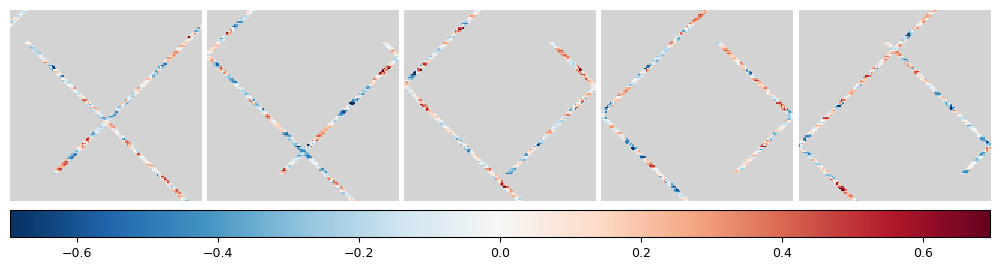

  Saved: figures/VarCM_spde/VarCM_spde_gt.png


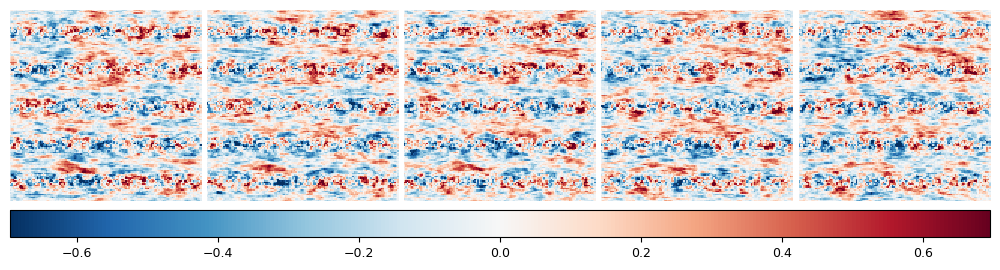

  Saved: figures/VarCM_spde/VarCM_spde_oi.png


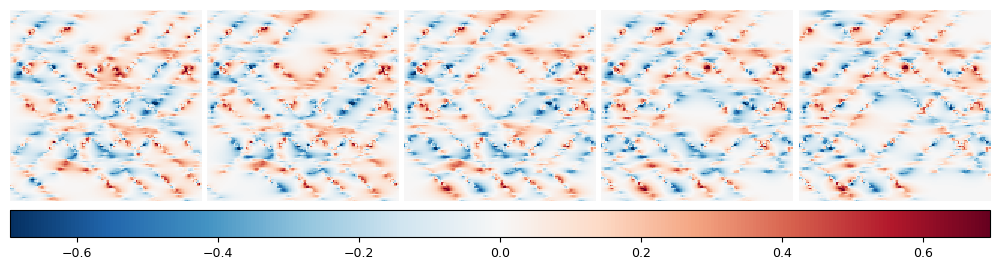

  Saved: figures/VarCM_spde/VarCM_spde_varcm_mean.png


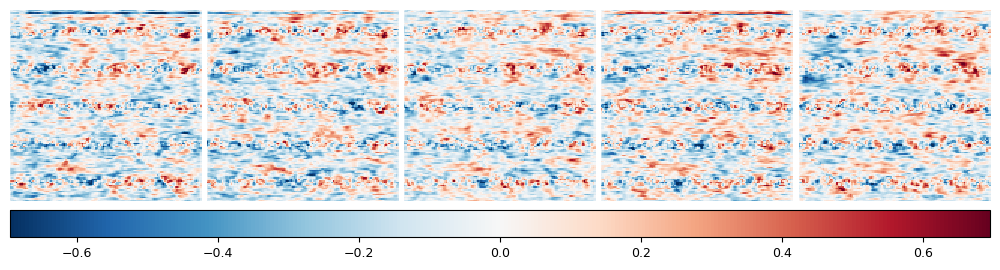

  Saved: figures/VarCM_spde/VarCM_spde_varcm_spread.png


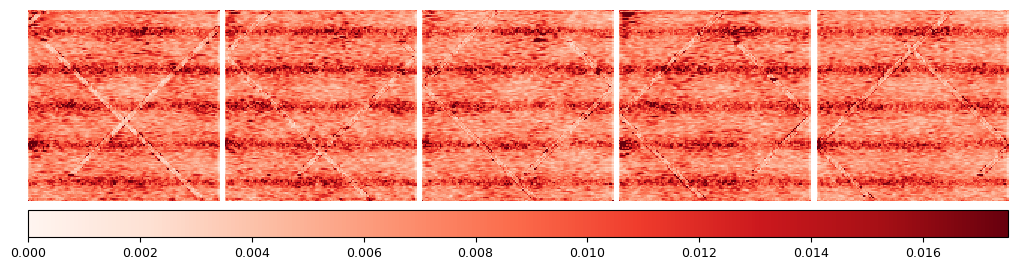

  Saved: figures/VarCM_spde/VarCM_spde_member0.png


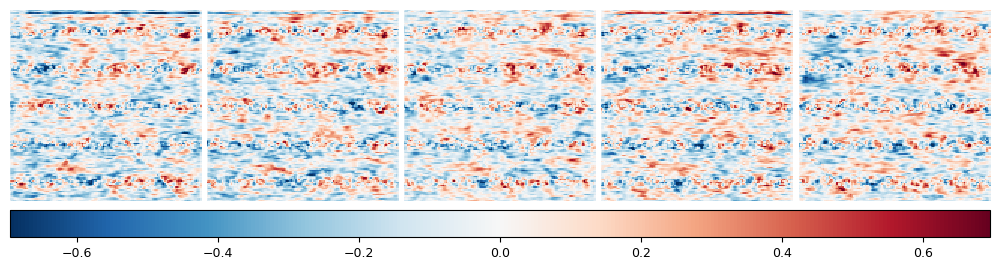

  Saved: figures/VarCM_spde/VarCM_spde_member1.png


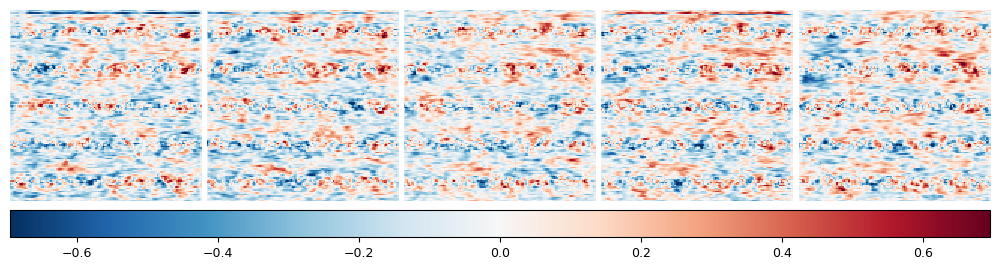

In [18]:
from matplotlib.gridspec import GridSpec

FIG_TAG = 'VarCM_spde'
FIG_DIR = os.path.join('figures', FIG_TAG)
os.makedirs(FIG_DIR, exist_ok=True)

C       = datamodule.window_size

# Physical fields over full assimilation window
m_norm, s_norm = datamodule.norm_stats()
start_t = datamodule.test_ds.indices[0]

obs_phys  = batch.input[0].float().numpy() * s_norm + m_norm   # (C,H,W) NaN ok
gt_phys   = batch.tgt[0].float().numpy()   * s_norm + m_norm   # (C,H,W)
oi_phys   = datamodule.oi[start_t: start_t + C].astype(np.float32)  # (C,H,W)
mean_phys = ens_mean.float().cpu().numpy() * s_norm + m_norm    # (C,H,W)
std_phys  = ens_std.float().cpu().numpy()  * s_norm             # (C,H,W)
mbr0_phys = ensemble[0].float().cpu().numpy() * s_norm + m_norm # (C,H,W)
mbr1_phys = ensemble[1].float().cpu().numpy() * s_norm + m_norm # (C,H,W)

# Shared colorbar range for all field images
vmax_f = float(np.nanpercentile(np.abs(gt_phys), 99))
vmin_f = -vmax_f
vmax_s = float(np.nanpercentile(std_phys, 99))

cmap_f = plt.cm.RdBu_r.copy(); cmap_f.set_bad('lightgray')
cmap_s = plt.cm.Reds.copy();   cmap_s.set_bad('lightgray')

def _save_strip(data, filename, vmin, vmax, cmap):
    # One image per variable: 1 row x C cols, horizontal colorbar, no title
    FW, FH, CB_H = 2.0, 2.0, 0.28
    fig_w = C * FW
    fig_h = FH + CB_H + 0.06
    fig = plt.figure(figsize=(fig_w, fig_h))
    gs = GridSpec(2, C,
                  left=0.01, right=0.99,
                  top=0.99,
                  bottom=0.01,
                  height_ratios=[FH, CB_H],
                  hspace=0.06, wspace=0.03)
    for c in range(C):
        ax = fig.add_subplot(gs[0, c])
        ax.imshow(data[c], origin='lower', cmap=cmap,
                  vmin=vmin, vmax=vmax, interpolation='nearest')
        ax.axis('off')
    ax_cb = fig.add_subplot(gs[1, :])
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
    sm.set_array([])
    cb = fig.colorbar(sm, cax=ax_cb, orientation='horizontal')
    cb.ax.tick_params(labelsize=9)
    fpath = os.path.join(FIG_DIR, f'{filename}.png')
    fig.savefig(fpath, dpi=200, bbox_inches='tight')
    print(f'  Saved: {fpath}')
    plt.show()

# One figure per variable (1 row x C cols, shared vmin/vmax per type)
figures = [
    (obs_phys,  f'{FIG_TAG}_obs',     vmin_f, vmax_f, cmap_f),
    (gt_phys,   f'{FIG_TAG}_gt',      vmin_f, vmax_f, cmap_f),
    (oi_phys,   f'{FIG_TAG}_oi',      vmin_f, vmax_f, cmap_f),
    (mean_phys, f'{FIG_TAG}_varcm_mean', vmin_f, vmax_f, cmap_f),
    (std_phys,  f'{FIG_TAG}_varcm_spread', 0.0,  vmax_s, cmap_s),
    (mbr0_phys, f'{FIG_TAG}_member0', vmin_f, vmax_f, cmap_f),
    (mbr1_phys, f'{FIG_TAG}_member1', vmin_f, vmax_f, cmap_f),
]

for data, fname, vmin, vmax, cmap in figures:
    _save_strip(data, fname, vmin, vmax, cmap)

### Transport Process — denoising trajectory (member 0)

  Saved: figures/VarCM_spde/VarCM_spde_transport.png


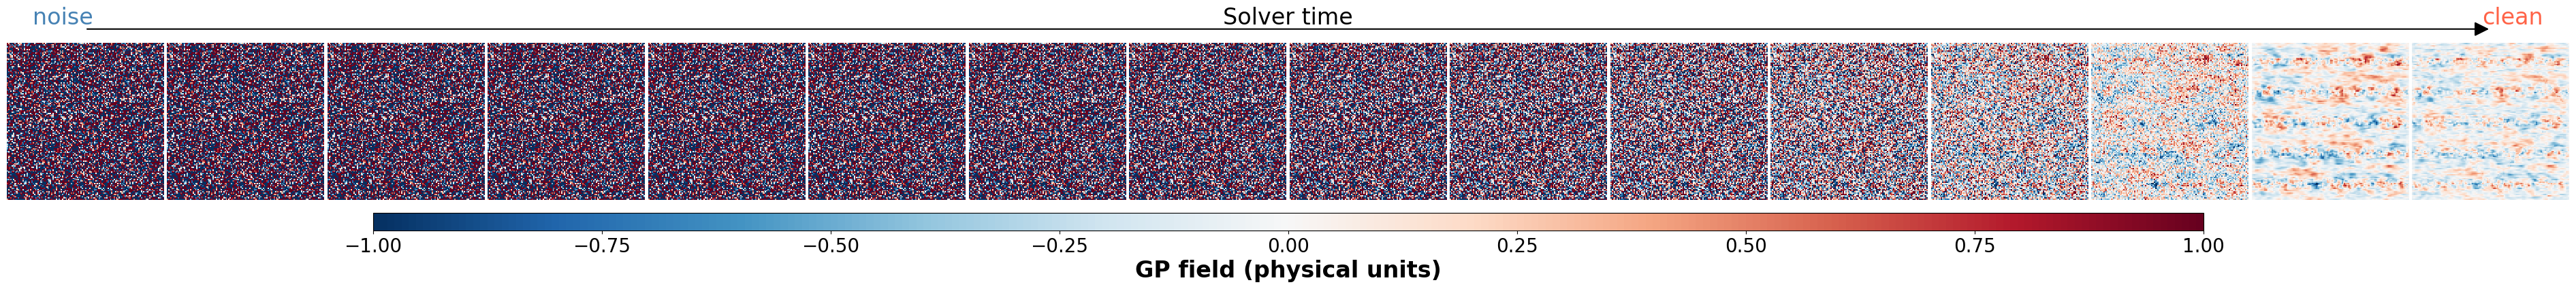

In [19]:
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

T_CH   = datamodule.window_size // 2   # displayed time channel (t=2)
N_SHOW = 10                             # max frames

proc = samples_process[0]
if proc.ndim == 5:   # (nsteps, B, C, H, W)
    transport_n = proc[:, 0, T_CH, :, :].float().cpu().numpy()
else:                # (nsteps, 1, C, H, W)
    transport_n = proc[:, 0, 0, T_CH, :, :].float().cpu().numpy()
transport_p = transport_n * s_norm + m_norm

nfr = transport_p.shape[0]
stride = max(1, nfr // N_SHOW)
idx_show = list(range(0, nfr, stride))
if (nfr - 1) not in idx_show:
    idx_show.append(nfr - 1)
frames = transport_p[idx_show]
nf = len(frames)

# Layout (all in inches, from bottom to top)
FW, FH   = 2.4, 2.4   # frame width / height
ARR_H    = 0.28        # arrow zone
GAP_1    = 0.14        # gap: arrow -> colorbar
CB_H     = 0.26        # colorbar height
GAP_2    = 0.16        # gap: colorbar -> images

fig_w = nf * FW
fig_h = ARR_H + GAP_1 + CB_H + GAP_2 + FH

# Figure-fraction positions (y = 0 at bottom)
arr_y_in   = ARR_H / 2                                # arrow center (inches)
cb_bot_in  = ARR_H + GAP_1                            # colorbar bottom (inches)
img_bot_in = ARR_H + GAP_1 + CB_H + GAP_2            # image strip bottom (inches)

arr_y_f   = arr_y_in   / fig_h
cb_bot_f  = cb_bot_in  / fig_h
cb_h_f    = CB_H       / fig_h
img_bot_f = img_bot_in / fig_h

fig = plt.figure(figsize=(fig_w, fig_h))

# Image strip (GridSpec leaves margins via bottom/top)
gs = GridSpec(1, nf, left=0.01, right=0.99,
              top=0.99, bottom=img_bot_f,
              hspace=0, wspace=0.02)

vmax_t = float(np.nanpercentile(np.abs(transport_p), 99))
vmax_t = 1
cmap_t = plt.cm.RdBu_r
for i in range(nf):
    ax = fig.add_subplot(gs[0, i])
    ax.imshow(frames[i], origin='lower', cmap=cmap_t,
              vmin=-vmax_t, vmax=vmax_t, interpolation='nearest')
    ax.axis('off')

# Horizontal colorbar
cb_ax = fig.add_axes([0.15, cb_bot_f, 0.70, cb_h_f])
sm = plt.cm.ScalarMappable(cmap=cmap_t, norm=plt.Normalize(-vmax_t, vmax_t))
sm.set_array([])
cb = fig.colorbar(sm, cax=cb_ax, orientation='horizontal')
cb.set_label('GP field (physical units)', fontsize=24, fontweight='bold')
cb.ax.tick_params(labelsize=20)

# Temporal arrow
fig.add_artist(mpatches.FancyArrowPatch(
    (0.04, 1+arr_y_f), (0.96, 1+arr_y_f),
    transform=fig.transFigure, arrowstyle='-|>',
    color='black', mutation_scale=32, linewidth=1.5,
))
fig.text(0.02, 1+arr_y_f, 'noise', va='bottom', ha='left',  fontsize=24, color='steelblue')
fig.text(0.98, 1+arr_y_f, 'clean', va='bottom', ha='right', fontsize=24, color='tomato')
fig.text(0.50, 1+arr_y_f, 'Solver time', va='bottom', ha='center', fontsize=24)

fpath = os.path.join(FIG_DIR, f'{FIG_TAG}_transport.png')
fig.savefig(fpath, dpi=200, bbox_inches='tight')
print(f'  Saved: {fpath}')
plt.show()

## 📊 Metrics — VarCM vs OI

Evaluation at the **centre of the assimilation window** (`t=2`, `C=5`).

| Metric | Description |
|---|---|
| **Score ↑** | $1 - \text{RMSE}/\sigma_{\text{GT}}$ |
| **RMSE ↓** | Root Mean Square Error vs GT |
| **σ_pred** | Standard deviation of the ensemble mean |
| **CRPS ↓** | Continuous Ranked Probability Score at **observed** pixels |
| **λx ↓** | Resolved scale (px): wavelength where spectral score = 0.5 |

[rank: 0] Global seed set to 42


Evaluated 225 (test sample, timestep) pairs across the full test set

## Metrics -- full test set (whole domain), n=225 (sample,t) pairs



,RMSE,lambda_x,CRPS
Method,,,
"VarCM (ens. mean, full test set)",0.2295 $\pm$ 0.0213,32.1 $\pm$ 31.5,0.0292 $\pm$ 0.0071
OI baseline (full test set),0.2253 $\pm$ 0.0040,43.1 $\pm$ 35.9,--


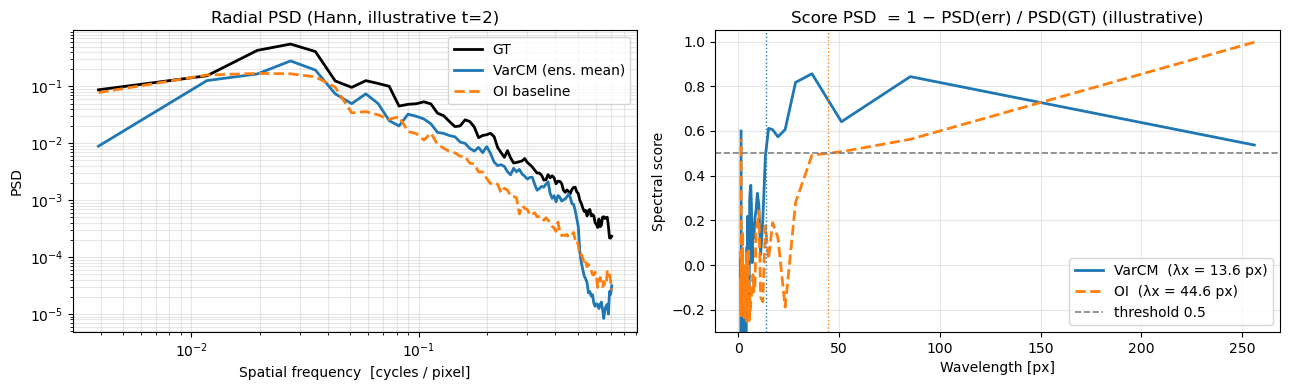

In [20]:
import sys
sys.path.append('../..')   # -> consistency/
from spectral_utils import radial_psd_2d, psd_spectral_score, resolved_scale

DX_PX  = 1.0                           # 1 pixel = 1 km (assumption)

m_norm, s_norm = datamodule.norm_stats()

# ── Full test-set evaluation ─────────────────────────────────────────────
# Loops over EVERY batch of datamodule.test_dataloader() (not just the first
# one used for the illustrative figures above) and EVERY timestep of the
# assimilation window (not just T_EVAL=window_size//2), regenerating a fresh
# ensemble each time via the variational consistency sampler, and comparing
# against the matching OI baseline slice for every (sample, timestep) pair.
# This is the expensive part (N_SAMPLES x n_test_samples sampling calls) --
# N_SAMPLES was reduced from 50 to 20 in methods.yaml specifically to keep a
# full-test-set pass affordable. SSH_GF is a continuous z-scored field, so
# unlike SIC there is no MIZ-style domain restriction -- metrics are
# aggregated over the whole spatial domain.
_all_vcm = {'score': [], 'rmse': [], 'sigma_gt': [], 'sigma_pred': [], 'crps': [], 'lambda_x': []}
_all_oi  = {'score': [], 'rmse': [], 'sigma_gt': [], 'sigma_pred': [], 'lambda_x': []}
_n_pairs = 0
_sample_counter = 0

seed_everything(42)
for _tb in datamodule.test_dataloader():
    _gt_b = _tb.tgt.to(device=device, dtype=dtype)      # (B, C, H, W)
    _y_b  = _tb.input.to(device=device, dtype=dtype)     # (B, C, H, W)
    _Bb, _Cb, _Hb, _Wb = _gt_b.shape
    _valid_b   = ~torch.isnan(_gt_b)
    _obsmask_b = ~torch.isnan(_y_b)

    for _bi in range(_Bb):
        _start_t = datamodule.test_ds.indices[_sample_counter]
        _sample_counter += 1

        with torch.no_grad():
            _members = []
            for _s in range(N_SAMPLES):
                _sample, _ = varcm_sampler(
                    unet, obs_cost, prior_cost, lambda_reg,
                    torch.randn((1, _Cb, _Hb, _Wb), device=device, dtype=dtype),
                    _y_b[_bi:_bi + 1],
                    nsteps=NSTEPS, clip_denoised=False, verbose=False,
                )
                _members.append(_sample.cpu())
        _ens_b = torch.stack(_members, dim=0).squeeze(1)   # (N, C, H, W) normalised
        _ens_mean_b = _ens_b.mean(0)                        # (C, H, W)

        for _t in range(_Cb):
            _valid_t = _valid_b[_bi, _t].cpu().numpy()
            if _valid_t.sum() < 10:
                continue
            _gt_p   = _gt_b[_bi, _t].float().cpu().numpy() * s_norm + m_norm
            _mean_p = _ens_mean_b[_t].float().numpy()       * s_norm + m_norm
            _ens_p  = _ens_b[:, _t].float().numpy()         * s_norm + m_norm
            _oi_p   = datamodule.oi[_start_t + _t].astype(np.float32)

            _gt_v, _pred_v = _gt_p[_valid_t], _mean_p[_valid_t]
            _sigma = float(np.std(_gt_v))
            if _sigma <= 0:
                continue
            _rmse  = float(np.sqrt(np.mean((_pred_v - _gt_v) ** 2)))
            _score = 1.0 - _rmse / _sigma
            _sigma_pred = float(np.std(_pred_v))

            _gt_f   = np.nan_to_num(_gt_p,   nan=0.0)
            _pred_f = np.nan_to_num(_mean_p, nan=0.0)
            _wl, _, _, _spec = psd_spectral_score(_pred_f, _gt_f, dx=DX_PX)
            _lam = resolved_scale(_wl, _spec, threshold=0.5)

            _crps_val = np.nan
            if HAS_PROPERSCORING:
                _obs_t  = _obsmask_b[_bi, _t].cpu().numpy()
                _obs_ij = np.argwhere(_valid_t & _obs_t)
                if len(_obs_ij) > 0:
                    _stride = max(1, len(_obs_ij) // 50)   # subsample -- CRPS is O(n) Python loop
                    _crps_val = float(np.mean([
                        crps_ensemble(float(_gt_p[i, j]), _ens_p[:, i, j])
                        for i, j in _obs_ij[::_stride]
                    ]))

            _all_vcm['score'].append(_score)
            _all_vcm['rmse'].append(_rmse)
            _all_vcm['sigma_gt'].append(_sigma)
            _all_vcm['sigma_pred'].append(_sigma_pred)
            _all_vcm['crps'].append(_crps_val)
            _all_vcm['lambda_x'].append(_lam)

            # OI baseline, same (sample, timestep) pair
            _oi_v = _oi_p[_valid_t]
            _rmse_oi  = float(np.sqrt(np.mean((_oi_v - _gt_v) ** 2)))
            _score_oi = 1.0 - _rmse_oi / _sigma
            _sigma_oi_pred = float(np.std(_oi_v))
            _oi_f = np.nan_to_num(_oi_p, nan=0.0)
            _wl_oi, _, _, _spec_oi = psd_spectral_score(_oi_f, _gt_f, dx=DX_PX)
            _lam_oi = resolved_scale(_wl_oi, _spec_oi, threshold=0.5)
            _all_oi['score'].append(_score_oi)
            _all_oi['rmse'].append(_rmse_oi)
            _all_oi['sigma_gt'].append(_sigma)
            _all_oi['sigma_pred'].append(_sigma_oi_pred)
            _all_oi['lambda_x'].append(_lam_oi)

            _n_pairs += 1

print(f"Evaluated {_n_pairs} (test sample, timestep) pairs across the full test set")

def _agg(vals):
    a = np.asarray(vals, dtype=float)
    a = a[~np.isnan(a)]
    return (float(np.mean(a)), float(np.std(a))) if len(a) else (np.nan, np.nan)

def _row(all_dict, label, has_crps=True):
    score_m, score_s = _agg(all_dict['score'])
    rmse_m, rmse_s   = _agg(all_dict['rmse'])
    sgt_m, sgt_s     = _agg(all_dict['sigma_gt'])
    spr_m, spr_s     = _agg(all_dict['sigma_pred'])
    lam_m, lam_s     = _agg(all_dict['lambda_x'])
    row = {
        'Method'     : label,
        'Score up'   : f'{score_m:.3f} ± {score_s:.3f}',
        'RMSE down'  : f'{rmse_m:.4f} ± {rmse_s:.4f}',
        'sigma_GT'   : f'{sgt_m:.4f} ± {sgt_s:.4f}',
        'sigma_pred' : f'{spr_m:.4f} ± {spr_s:.4f}',
        'lambda_x px': f'{lam_m:.1f} ± {lam_s:.1f}' if not np.isnan(lam_m) else '?',
    }
    if has_crps:
        crps_m, crps_s = _agg(all_dict['crps'])
        row['CRPS down'] = f'{crps_m:.4f} ± {crps_s:.4f}' if not np.isnan(crps_m) else '--'
    return row

row_vcm = _row(_all_vcm, 'VarCM (ens. mean, full test set)', has_crps=True)
row_oi  = _row(_all_oi,  'OI baseline (full test set)',       has_crps=False)
row_oi['CRPS down'] = '--'

df_metrics = pd.DataFrame([row_vcm, row_oi]).set_index('Method')
df_metrics = df_metrics[['Score up','RMSE down','sigma_GT','sigma_pred','CRPS down','lambda_x px']]
df_metrics.columns = ['Score ↑','RMSE ↓','σ_GT','σ_pred','CRPS ↓','λx [px]']
print(f'\n## Metrics -- full test set (whole domain), n={_n_pairs} (sample,t) pairs\n')

# ── Canonicalize columns for the cross-method LaTeX table (make_latex_table.py) ──
# Every notebook in the suite must expose the SAME column names (RMSE,
# lambda_x, CRPS) regardless of internal naming (unicode arrows/sigma vs
# plain ascii, [px]/[deg] unit suffixes) -- otherwise make_latex_table.py's
# column-union logic creates duplicate columns (e.g. both "RMSE" and
# "RMSE ↓") instead of one shared column per metric. Score/sigma_GT/sigma_pred
# are dropped (not part of the target table). "±" is replaced with the
# LaTeX-safe "$\pm$" so the aggregated .tex table compiles cleanly.
_col_map = {
    'RMSE': 'RMSE', 'RMSE ↓': 'RMSE', 'RMSE down': 'RMSE',
    'lambda_x': 'lambda_x', 'lambda_x [px]': 'lambda_x', 'lambda_x [deg]': 'lambda_x',
    'lambda_x px': 'lambda_x', 'lambda_x [km]': 'lambda_x',
    'λx [px]': 'lambda_x', 'λx [deg]': 'lambda_x', 'λx px': 'lambda_x', 'λx [km]': 'lambda_x',
    'CRPS': 'CRPS', 'CRPS ↓': 'CRPS', 'CRPS down': 'CRPS',
}
df_metrics = df_metrics.rename(columns=_col_map)
for _c in df_metrics.columns:
    df_metrics[_c] = df_metrics[_c].apply(lambda v: v.replace('±', '$\\pm$') if isinstance(v, str) else v)
_keep = [c for c in ['RMSE', 'lambda_x', 'CRPS'] if c in df_metrics.columns]
df_metrics = df_metrics[_keep]

display(df_metrics)

# ── Illustrative PSD plot (single example, T_EVAL=window_size//2 of the first
# test batch, same one used by the figures above) -- qualitative check only,
# NOT the quantitative table (that's df_metrics above, full test set now).
T_EVAL = datamodule.window_size // 2
start_t = datamodule.test_ds.indices[0]
gt_p_ex   = batch.tgt[0, T_EVAL].float().numpy() * s_norm + m_norm
mean_p_ex = ens_mean[T_EVAL].float().cpu().numpy() * s_norm + m_norm
oi_p_ex   = datamodule.oi[start_t + T_EVAL].astype(np.float32)

wl_gt,   psd_gt_sig   = radial_psd_2d(gt_p_ex,   dx=DX_PX)
wl_vcm2, psd_vcm_sig  = radial_psd_2d(mean_p_ex, dx=DX_PX)
wl_oi2,  psd_oi_sig   = radial_psd_2d(oi_p_ex,   dx=DX_PX)
wl_vcm, _, _, spec_vcm = psd_spectral_score(mean_p_ex, gt_p_ex, dx=DX_PX)
wl_oi,  _, _, spec_oi  = psd_spectral_score(oi_p_ex,   gt_p_ex, dx=DX_PX)
lambda_x_vcm = resolved_scale(wl_vcm, spec_vcm)
lambda_x_oi  = resolved_scale(wl_oi,  spec_oi)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
for wl, psd, color, ls, lbl in [
    (wl_gt,   psd_gt_sig,   'black',  '-',  'GT'),
    (wl_vcm2, psd_vcm_sig,  'C0',     '-',  'VarCM (ens. mean)'),
    (wl_oi2,  psd_oi_sig,   'C1',     '--', 'OI baseline'),
]:
    v = np.isfinite(wl) & np.isfinite(psd) & (wl > 0) & (psd > 0)
    ax.loglog(1.0/wl[v], psd[v], color=color, ls=ls, lw=2, label=lbl)
ax.set_xlabel('Spatial frequency  [cycles / pixel]')
ax.set_ylabel('PSD')
ax.set_title(f'Radial PSD (Hann, illustrative t={T_EVAL})')
ax.legend()
ax.grid(True, which='both', alpha=0.3)

ax = axes[1]
lbl_vcm = f'VarCM  (λx = {lambda_x_vcm:.1f} px)' if not np.isnan(lambda_x_vcm) else 'VarCM'
lbl_oi  = f'OI  (λx = {lambda_x_oi:.1f} px)'      if not np.isnan(lambda_x_oi)  else 'OI'
for wl, spec, color, ls, lbl in [
    (wl_vcm, spec_vcm, 'C0', '-',  lbl_vcm),
    (wl_oi,  spec_oi,  'C1', '--', lbl_oi),
]:
    v = np.isfinite(wl) & np.isfinite(spec)
    ax.plot(wl[v], spec[v], color=color, ls=ls, lw=2, label=lbl)
ax.axhline(0.5, color='gray', lw=1.2, ls='--', label='threshold 0.5')
if not np.isnan(lambda_x_vcm):
    ax.axvline(lambda_x_vcm, color='C0', lw=1, ls=':')
if not np.isnan(lambda_x_oi):
    ax.axvline(lambda_x_oi, color='C1', lw=1, ls=':')
ax.set_xlabel('Wavelength [px]')
ax.set_ylabel('Spectral score')
ax.set_title('Score PSD  = 1 − PSD(err) / PSD(GT) (illustrative)')
ax.set_ylim(-0.3, 1.05)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [21]:
# --- metrics serialization (patch_notebook_params.py) ---
import os
os.makedirs(os.path.dirname(METRICS_CSV) or '.', exist_ok=True)
_df_out = df_metrics.reset_index() if df_metrics.index.name == 'Method' else df_metrics
_df_out.to_csv(METRICS_CSV, index=False)
print(f'Metrics written to {METRICS_CSV}')


Metrics written to /Odyssey/private/m19beauc/4dvarnet-starter-devs/consistency/sbatch_submission/results/GP/VarCM_metrics.csv
